# Pertemuan 3: Linear Regression & Polynomial Regression

In [1]:
# Import library
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error

In [2]:
# Load dataset mpg
df = sns.load_dataset("mpg")

# hapus missing value
df = df.dropna()

print("Shape data:", df.shape)
df.head()

Shape data: (392, 9)


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


In [3]:
# 1. Simple Linear Regression
# fitur: horsepower
# target: mpg

X = df[['horsepower']]
y = df['mpg']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model_simple = LinearRegression()
model_simple.fit(X_train, y_train)

y_pred_simple = model_simple.predict(X_test)

print("Simple Linear Regression")
print("MAE :", round(mean_absolute_error(y_test, y_pred_simple),3))
print("RMSE:", round(root_mean_squared_error(y_test, y_pred_simple),3))
print("R2  :", round(r2_score(y_test, y_pred_simple),3))

Simple Linear Regression
MAE : 3.783
RMSE: 4.707
R2  : 0.566


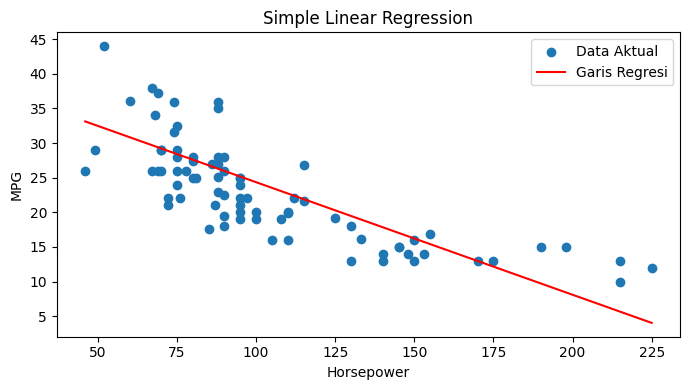

In [4]:
# Visualisasi garis regresi
plt.figure(figsize=(7,4))

plt.scatter(X_test, y_test, label="Data Aktual")

sorted_idx = np.argsort(X_test['horsepower'])
plt.plot(
    X_test['horsepower'].values[sorted_idx],
    y_pred_simple[sorted_idx],
    color="red",
    label="Garis Regresi"
)

plt.xlabel("Horsepower")
plt.ylabel("MPG")
plt.title("Simple Linear Regression")
plt.legend()

plt.tight_layout()
plt.show()

In [5]:
# 2. Multiple Linear Regression
# minimal 3 fitur

features = ['horsepower','weight','acceleration']
X_multi = df[features]
y = df['mpg']

X_train, X_test, y_train, y_test = train_test_split(
    X_multi, y, test_size=0.2, random_state=42
)

model_multi = LinearRegression()
model_multi.fit(X_train, y_train)

y_pred_multi = model_multi.predict(X_test)

print("Multiple Linear Regression")
print("MAE :", round(mean_absolute_error(y_test, y_pred_multi),3))
print("RMSE:", round(root_mean_squared_error(y_test, y_pred_multi),3))
print("R2  :", round(r2_score(y_test, y_pred_multi),3))

Multiple Linear Regression
MAE : 3.506
RMSE: 4.221
R2  : 0.651


In [6]:
# 3. Polynomial Regression
# bandingkan degree 1 vs degree 2


X = df[['horsepower']]
y = df['mpg']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Degree 1
model_d1 = LinearRegression()
model_d1.fit(X_train, y_train)

# Degree 2
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

model_d2 = LinearRegression()
model_d2.fit(X_train_poly, y_train)

r2_d1 = model_d1.score(X_test, y_test)
r2_d2 = model_d2.score(X_test_poly, y_test)

print("Perbandingan Polynomial")
print("R2 Degree 1:", round(r2_d1,3))
print("R2 Degree 2:", round(r2_d2,3))

Perbandingan Polynomial
R2 Degree 1: 0.566
R2 Degree 2: 0.639


In [7]:
# Evaluasi model polynomial

y_pred_poly = model_d2.predict(X_test_poly)

print("Polynomial Regression (Degree 2)")
print("MAE :", round(mean_absolute_error(y_test, y_pred_poly),3))
print("RMSE:", round(root_mean_squared_error(y_test, y_pred_poly),3))
print("R2  :", round(r2_score(y_test, y_pred_poly),3))

Polynomial Regression (Degree 2)
MAE : 3.264
RMSE: 4.291
R2  : 0.639
